## Import Libraries

In [5]:
import sys
print(sys.executable)

c:\Users\SURAJ\anaconda3\python.exe


## Prophet install issue resolution 


In [6]:
import sys
!{sys.executable} -m pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.99-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.99-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ----------

In [7]:
# Import the tools we need
import pandas as pd                # for working with data
import matplotlib.pyplot as plt    # for making charts
from prophet import Prophet        # for forecasting future sales
import warnings
warnings.filterwarnings('ignore')  # hide unnecessary warnings

print("Libraries ready!")

Libraries ready!


##  Load Data

In [8]:
    # Load our cleaned dataset
df = pd.read_csv('../data/superstore_cleaned.csv')

# Group sales by year and month
# This gives us total sales for each month
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

# Prophet needs dates in a column called 'ds'
# and values in a column called 'y'
# So we create those columns
monthly['ds'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' +   # year
    monthly['Order Month'].astype(str) + '-01'  # month, day=01
)
monthly['y'] = monthly['Sales']  # y = sales value

# Keep only ds and y columns for Prophet
prophet_df = monthly[['ds', 'y']].reset_index(drop=True)

print("Data ready!")
print("Total months of data:", len(prophet_df))
prophet_df.head()

Data ready!
Total months of data: 48


,ds,y
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


## Train the Forecasting Model

In [10]:
# Create the Prophet model
# yearly_seasonality=True means it will learn yearly patterns
model = Prophet(yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False)

# Train the model on our data
model.fit(prophet_df)

print("Model trained successfully!")

17:11:31 - cmdstanpy - INFO - Chain [1] start processing
17:11:32 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


## Predict Next 6 Months

In [11]:
# Tell Prophet to predict 6 months into the future
# freq='MS' means Month Start
future = model.make_future_dataframe(periods=6, freq='MS')

# Generate predictions
forecast = model.predict(future)

# Show only the next 6 months predictions
print("Next 6 Months Sales Forecast:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6).to_string(index=False))

# yhat       = predicted sales
# yhat_lower = lowest possible sales
# yhat_upper = highest possible sales

Next 6 Months Sales Forecast:
        ds         yhat   yhat_lower   yhat_upper
2018-01-01 45772.770285 37053.600041 54292.003693
2018-02-01 32975.255105 23991.681254 42326.712919
2018-03-01 72181.347653 63068.240271 80660.942820
2018-04-01 56487.020266 48251.880000 65413.054858
2018-05-01 57101.042381 47788.997181 65528.540642
2018-06-01 58654.769257 50174.177951 67339.386008


## Ploting the Forecast Chart

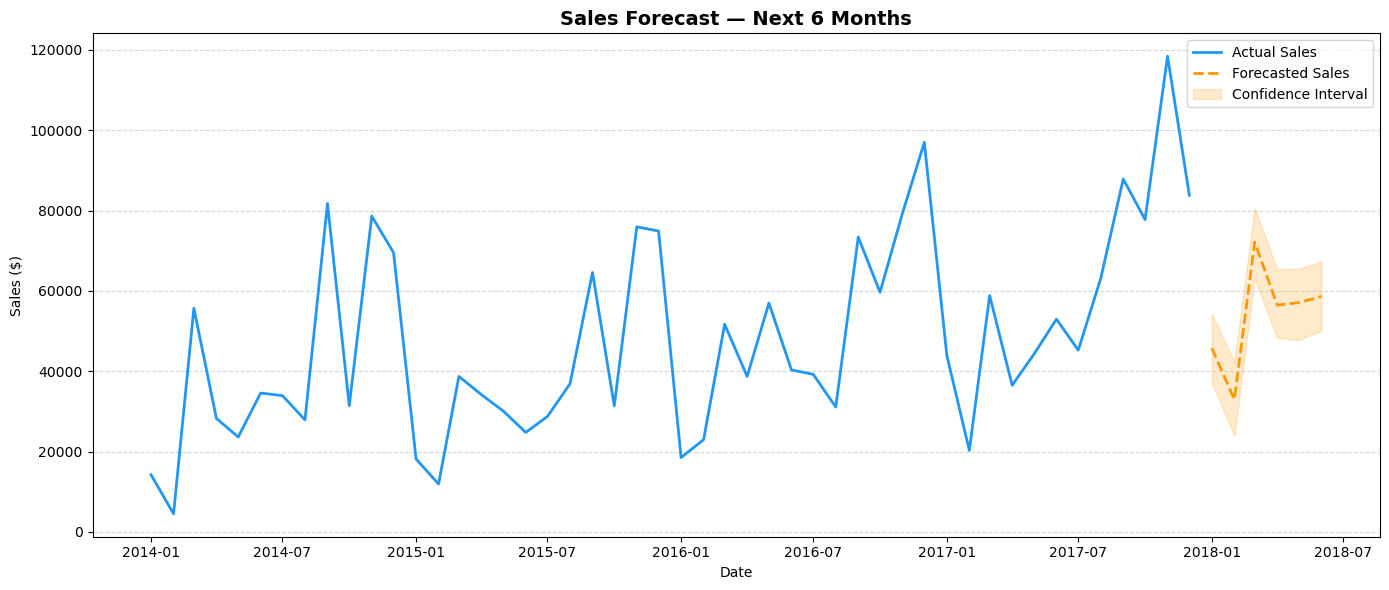

 Forecast chart saved!


In [13]:
# Create a chart showing actual vs predicted sales
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual sales (blue line)
ax.plot(prophet_df['ds'], prophet_df['y'],
        color='#2196F3', linewidth=2, label='Actual Sales')

# Get only forecasted 6 months
forecast_only = forecast.tail(6)

# Plot predicted sales (orange dashed line)
ax.plot(forecast_only['ds'], forecast_only['yhat'],
        color='#FF9800', linewidth=2,
        linestyle='--', label='Forecasted Sales')

# Show confidence range (shaded area)
ax.fill_between(forecast_only['ds'],
                forecast_only['yhat_lower'],  # lower bound
                forecast_only['yhat_upper'],  # upper bound
                alpha=0.2, color='#FF9800',
                label='Confidence Interval')

# Chart labels
ax.set_title('Sales Forecast — Next 6 Months', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Save chart
plt.tight_layout()
plt.savefig('../outputs/03_sales_forecast.png', dpi=150)
plt.show()
print(" Forecast chart saved!")

## Show Seasonal Patterns

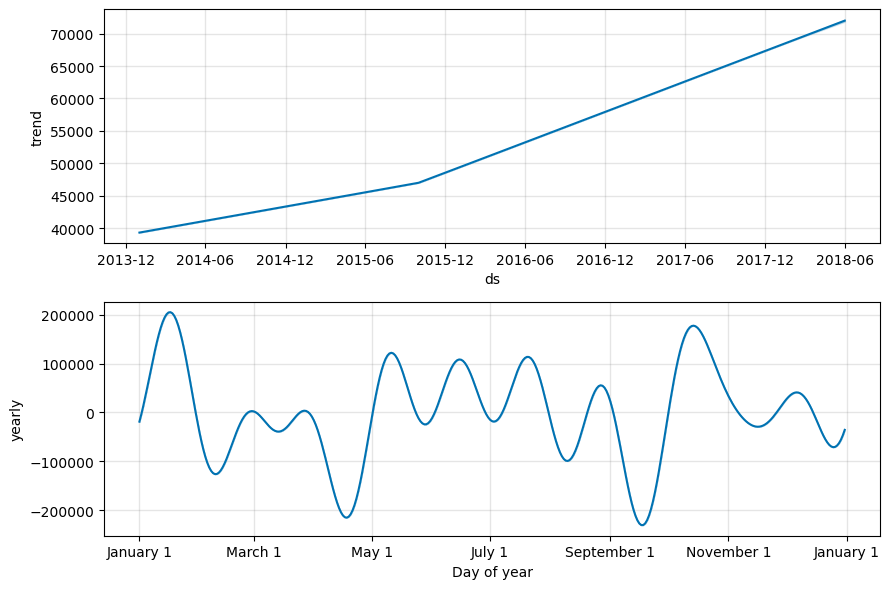

Seasonal trends chart saved!


In [15]:
# This chart shows:
# 1. Overall trend (going up or down over years)
# 2. Yearly seasonality (which months are best/worst)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('../outputs/03_forecast_components.png', dpi=150)
plt.show()
print("Seasonal trends chart saved!")

## Business Summary

In [16]:
# Get the 6 month forecast in a clean table
forecast_6 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6).copy()

# Rename columns to readable names
forecast_6.columns = ['Month', 'Predicted Sales', 'Lower Bound', 'Upper Bound']

# Format month as readable date
forecast_6['Month'] = forecast_6['Month'].dt.strftime('%B %Y')

# Round all numbers
forecast_6 = forecast_6.round(2)

# Print summary
print("=" * 55)
print("6 MONTH SALES FORECAST")
print("=" * 55)
print(forecast_6.to_string(index=False))

# Total and average
total = forecast_6['Predicted Sales'].sum()
avg   = forecast_6['Predicted Sales'].mean()
print(f"\nTotal Predicted Revenue (6 months): ${total:,.2f}")
print(f"Average Monthly Revenue            : ${avg:,.2f}")

6 MONTH SALES FORECAST
        Month  Predicted Sales  Lower Bound  Upper Bound
 January 2018         45772.77     37053.60     54292.00
February 2018         32975.26     23991.68     42326.71
   March 2018         72181.35     63068.24     80660.94
   April 2018         56487.02     48251.88     65413.05
     May 2018         57101.04     47789.00     65528.54
    June 2018         58654.77     50174.18     67339.39

Total Predicted Revenue (6 months): $323,172.21
Average Monthly Revenue            : $53,862.04


## Save Results

In [17]:
# Save forecast table as CSV
forecast_6.to_csv('../outputs/sales_forecast_6months.csv', index=False)
print("Forecast results saved to outputs folder!")

Forecast results saved to outputs folder!
